# 📺 Netflix Data Analysis

## Project Objective 🎯

This project analyzes the Netflix Movies and TV Shows dataset using Python and Pandas and data visualization.

The objective is to:

- Perform data cleaning
- Explore the dataset
- Answer business questions
- Create meaningful visualizations
- Generate actionable insights

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Streamlit

#### 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")    #Better looking charts
plt.rcParams["figure.figsize"] = (12, 6)    #Bigger charts
pd.set_option('display.max_columns', None)      #Display all columns if needed

#### 2. Load Dataset

In [4]:
df = pd.read_csv("../data/netflix_titles.csv")

In [14]:
df.head()
df.tail()
df.shape
df.info()
df.describe() #include="object" for string columns
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

##### 3. Data Quality Assessment
In this section, we inspect the dataset for common quality issues such as:

- Missing values
- Duplicate rows
- Duplicate titles
- Data types

In [7]:
#Check for missing values 
df.isnull().sum()

#Create dataframe to show missing values and percentage of missing values
missing = pd.DataFrame({
    "Missing values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean() * 100, 2)
})
missing.sort_values(by="Percentage", ascending=False)

df.duplicated().sum()
df["title"].duplicated().sum()

np.int64(0)

#### 4. Data Cleaning

In this section, we will:

- Handle missing values
- Convert data types
- Prepare columns for analysis

In [9]:
# Create a copy of the original DataFrame to clean
# It's a good practice to keep the original data intact for reference and comparison later
df_clean = df.copy()

In [10]:
# Fill missing values with "Unknown" to avois issues relating to null values in the analysis and visualizations
columns_to_fill = ["director", "cast", "country", "rating", "duration"]

for column in columns_to_fill:
    df_clean[column] = df_clean[column].fillna("Unknown")

In [12]:
#Checking the data type of the 'date_added' column
df_clean['date_added'].dtype 

<StringDtype(na_value=nan)>

In [13]:
# Remove extra spaces from the 'date_added' column using str.strip() method
df_clean['date_added'] = df_clean['date_added'].str.strip()

# Now, convert the 'date_added' column to datetime format to avoid conversion issues
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')

In [14]:
#info returns basis overview of the dataframe
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 3.8 MB


In [15]:
df_clean['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [61]:
#Check for missing values after cleaning
df_clean['date_added'].isnull().sum() 

np.int64(10)

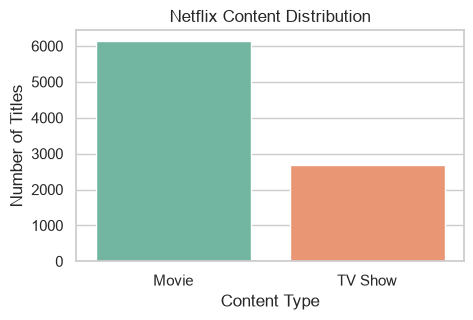

In [22]:
# Visualizing the distribution of content types in the cleaned dataset using a countplot with Seaborn. 
# The plot will show the number of titles for each content type (e.g., Movie, TV Show) in the Netflix dataset.
plt.figure(figsize=(5,3))

sns.countplot(
    data=df_clean,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Netflix Content Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

# Saving the plot as a PNG file in the specified directory with a resolution of 300 DPI 
# and tight bounding box to ensure that all elements of the plot are included in the saved image to upload in github.
plt.savefig(
    "../outputs/charts/content_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5. Exploratory Data Analysis

##### # 5.1 Movies vs TV Shows Distribution

In [23]:
#Checking the count of each content type in the cleaned dataset
df_clean['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

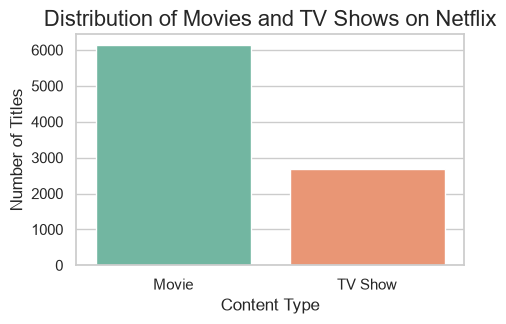

In [24]:
# Visualizing the distribution of Movies and TV Shows in the cleaned dataset using a countplot with Seaborn.
# The plot will show the number of titles for each content type (e.g., Movie, TV Show) in the Netflix dataset.
plt.figure(figsize=(5,3))

sns.countplot(
    data=df_clean,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Movies and TV Shows on Netflix", fontsize=16)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.savefig(
    "../outputs/charts/movies_vs_tvshows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
#A simple countplot is good, but let's make it more informative by adding percentages.
content_type = df_clean["type"].value_counts()

content_percentage = (
    content_type / content_type.sum() * 100
).round(2)

content_percentage

type
Movie      69.62
TV Show    30.38
Name: count, dtype: float64

##### # 5.2 Movies vs TV Shows Percentage

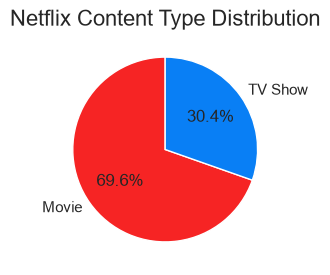

In [ ]:
#Visualizing the distribution of content types in the cleaned dataset using a pie chart with Matplotlib.
plt.figure(figsize=(5,3))

plt.pie(
    content_type,
    labels=content_type.index,
    autopct="%1.1f%%",  #TO MANAGE THE NUMBERS AFTER DECIMAL POINT
    startangle=90,
    colors=["#f62424", "#097ff5"]
)

plt.title("Netflix Content Type Distribution", fontsize=16)
plt.savefig("../outputs/charts/content_type_percentage.png", 
            dpi=300, 
            bbox_inches="tight"
)

plt.show()

In [28]:
df_clean["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

####  # 5.3 Netflix Content Added Over Time

In [30]:
#Extracting the year from the 'date_added' column and creating a new column 'year_added' in the cleaned DataFrame. 
#This will allow for analysis of trends over time, such as how many titles were added each year.
df_clean["year_added"] = df_clean['date_added'].dt.year

In [31]:
df_clean["year_added"].head()

0    2021.0
1    2021.0
2    2021.0
3    2021.0
4    2021.0
Name: year_added, dtype: float64

In [33]:
#Extracting the number of titles added each year to analyze trends over time.
df_clean[["date_added", "year_added"]].head()

titles_per_year = (
    df_clean["year_added"]
    .value_counts()
    .sort_index()
)

titles_per_year

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

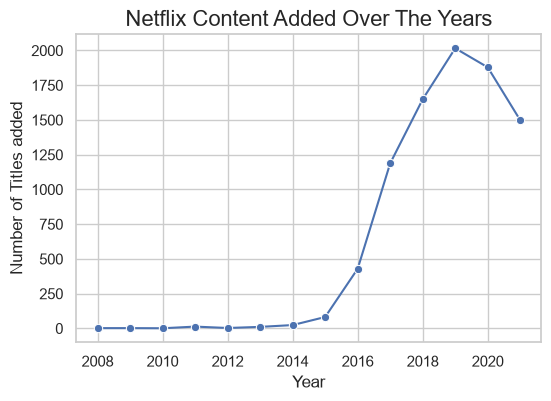

In [38]:
#Visualizing the number of titles added to Netflix each year using a line plot with Seaborn.
plt.figure(figsize=(6,4))

sns.lineplot(
    x=titles_per_year.index,
    y=titles_per_year.values,
    marker="o"
)

plt.title(
    "Netflix Content Added Over The Years",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Number of Titles added")

plt.xticks(rotation=0)

plt.savefig(
    "../outputs/charts/content_growth_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### # 5.4 Netflix Contents by Country

In [41]:
df_clean["country"].head(10)
#Some countries have more than one country listed, separated by commas.

0                                        United States
1                                         South Africa
2                                              Unknown
3                                              Unknown
4                                                India
5                                              Unknown
6                                              Unknown
7    United States, Ghana, Burkina Faso, United Kin...
8                                       United Kingdom
9                                        United States
Name: country, dtype: str

#####  Here,
        Some titles have multiple countries.
        Example:
        United States, India

        If we count directly:
        value_counts()

        we would treat this as one country.
        But actually it represents two countries.
        So we need to split the values.

In [42]:
# Create a new dataframe to analyze content distribution by country.
country_df = df_clean.copy()

# Now, split the 'country' column into multiple rows for each country listed in a title's entry. 
country_df["country"] = country_df["country"].str.split(", ")

country_df = country_df.explode("country")      #Now each country gets counted separately.

In [43]:
#Extarcting the top 10 countries with the most content on Netflix to analyze content distribution by country.
country_counts = (
    country_df["country"]
    .value_counts()
    .head(10)
)

country_counts

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

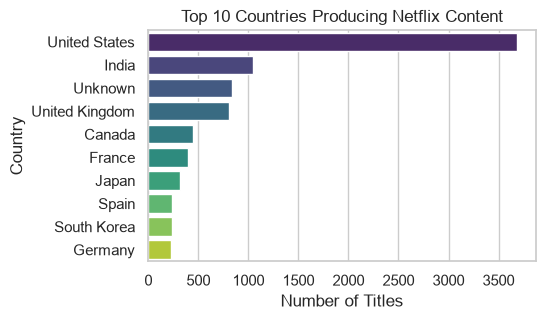

In [44]:
# Visualize the top 10 countries with the most Netflix content
plt.figure(figsize=(5,3))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    hue=country_counts.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Countries Producing Netflix Content",
    fontsize=12
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.savefig(
    "../outputs/charts/top_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###### The United States dominates Netflix's content library, producing significantly more movies and TV shows than other countries. India and the United Kingdom are the next largest contributors, showing strong representation from both Asian and European markets.

### Removing unknown

In [45]:
#Dropping the "Unknown" country from the country counts to focus on known countries in the analysis.
country_counts_clean = country_counts.drop("Unknown")
country_counts_clean

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

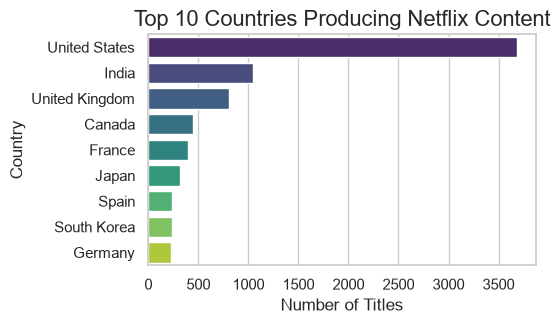

In [46]:
#Visualize the top 10 countries with the most Netflix content, excluding "Unknown" country.
plt.figure(figsize=(5,3))

sns.barplot(
    x=country_counts_clean.values,
    y=country_counts_clean.index,
    hue=country_counts_clean.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Countries Producing Netflix Content",
    fontsize=16
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.savefig(
    "../outputs/charts/top_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 6. Genre Analysis

###### Goal: To find the most common genres on Netflix.

In [47]:
# Create copy
genre_df = df_clean.copy()

# Split genres
genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")

# Expand genres
genre_df = genre_df.explode("listed_in")

# Count genres
genre_counts = (
    genre_df["listed_in"]
    .value_counts()
    .head(10)
)

genre_counts

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

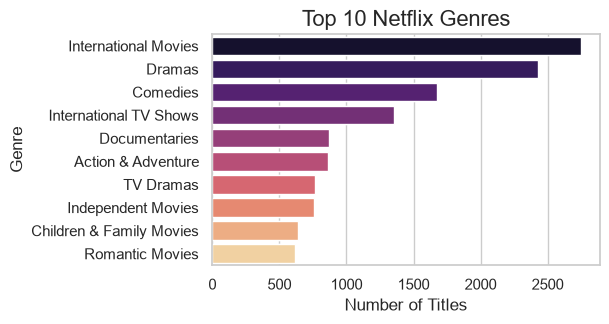

In [103]:
# Visualization of the top 10 genres on Netflix
plt.figure(figsize=(5,3))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    hue=genre_counts.index,
    palette="magma",
    legend=False
)

plt.title(
    "Top 10 Netflix Genres",
    fontsize=16
)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    hue=genre_counts.index,
    palette="magma",
    legend=False
)

plt.title(
    "Top 10 Netflix Genres",
    fontsize=16
)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.savefig(
    "../outputs/charts/top_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 7. Rating Analysis

##### Goal: To Understand Netflix content ratings.

In [48]:
#Analysis of the distribution of content ratings of Netflix contents
rating_counts = (
    df_clean["rating"]
    .value_counts()
)

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

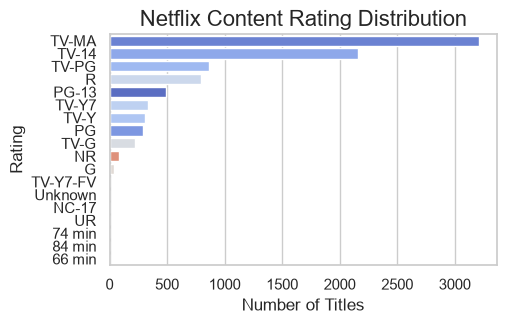

In [52]:
# Visualizing the distribution of content ratings using a countplot with Seaborn.
plt.figure(figsize=(5,3))

sns.countplot(
    data=df_clean,
    y="rating",
    order=df_clean["rating"].value_counts().index,
    hue="rating",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Netflix Content Rating Distribution",
    fontsize=16
)

plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.savefig(
    "../outputs/charts/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 7. Director Analysis

##### Goal: To find directors with the most Netflix titles.

In [54]:
director_counts = (
    df_clean[df_clean["director"] != "Unknown"]
    ["director"]
    .value_counts()
    .head(10)
)

director_counts

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

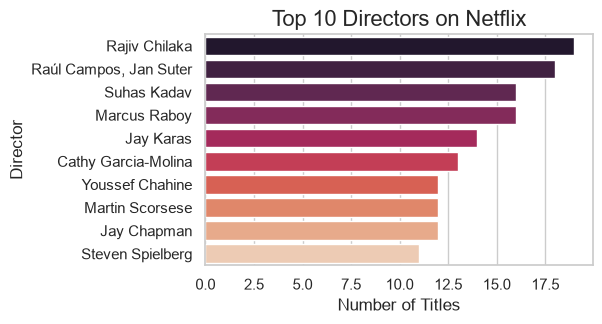

In [55]:
#Visualizing the top 10 directors on Netflix using a bar plot with Seaborn.
plt.figure(figsize=(5,3))

sns.barplot(
    x=director_counts.values,
    y=director_counts.index,
    hue=director_counts.index,
    palette="rocket",
    legend=False
)

plt.title(
    "Top 10 Directors on Netflix",
    fontsize=16
)

plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.savefig(
    "../outputs/charts/top_directors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 8. Duration Analysis 

This is a more advanced section because duration contains mixed data:
Examples:
- 90 min
- 3 Seasons

We need to separate:
- Movie duration
- TV Show seasons

##### Part A: Movies Duration

In [57]:
movies = df_clean[df_clean["type"] == "Movie"].copy()

In [58]:
#Extracting minutes
movies["duration_minutes"] = (
    movies["duration"]
    .str.extract("(\d+)")
    .astype(float)
)
movies[["duration","duration_minutes"]].head()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Roshni\AppData\Local\Temp\ipykernel_19484\648894305.py:4: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


,duration,duration_minutes
0,90 min,90.0
6,91 min,91.0
7,125 min,125.0
9,104 min,104.0
12,127 min,127.0


In [112]:
# Average movie length
average_movie_length = (
    movies["duration_minutes"]
    .mean()
)

average_movie_length

np.float64(99.57718668407311)

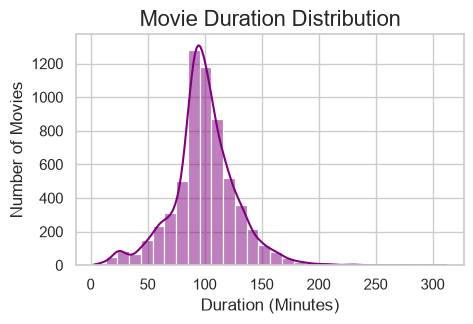

In [59]:
# Visualizing the distribution of movie durations using a histogram with Seaborn. 
# The histogram will show how movie lengths are distributed across different duration ranges, 
# and the kernel density estimate (KDE) will provide a smooth curve representing the distribution.
plt.figure(figsize=(5,3))

sns.histplot(
    movies["duration_minutes"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title(
    "Movie Duration Distribution",
    fontsize=16
)

plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

Part B: TV Show Seasons

In [63]:
tv_shows = df_clean[df_clean["type"] == "TV Show"].copy()

In [64]:
tv_shows["seasons"] = (
    tv_shows["duration"]
    .str.extract("(\d+)")
    .astype(float)
)

tv_shows[
    ["duration","seasons"]
].head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Roshni\AppData\Local\Temp\ipykernel_19484\1546374904.py:3: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


,duration,seasons
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0
5,1 Season,1.0


In [65]:
# most common number of seasons
season_counts = (
    tv_shows["seasons"]
    .value_counts()
    .sort_index()
)

season_counts

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64

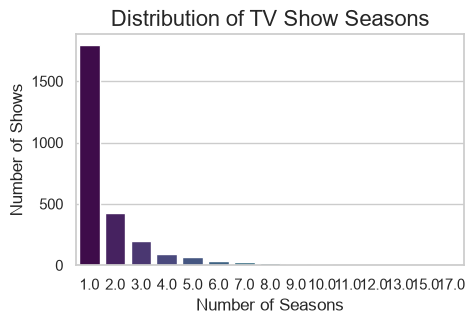

In [66]:
# Visualizing the distribution of TV show seasons using a countplot with Seaborn.
plt.figure(figsize=(5,3))

sns.countplot(
    data=tv_shows,
    x="seasons",
    hue="seasons",
    palette="viridis",
    legend=False
)

plt.title(
    "Distribution of TV Show Seasons",
    fontsize=16
)

plt.xlabel("Number of Seasons")
plt.ylabel("Number of Shows")

plt.show()

#### 10. Movie v/s TV Show Trend Over Years

##### Question:
How has Netflix's content type changed over time?

In [68]:
# Remove missing years
trend_df = df_clean.dropna(subset=["year_added"])

# Count type by year
type_year = (
    trend_df
    .groupby(["year_added", "type"])
    .size()
    .reset_index(name="count")
)

type_year.head()

,year_added,type,count
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13


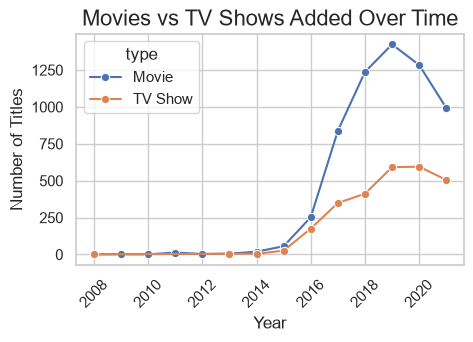

In [69]:
#Visualizing the number of Movies and TV Shows added to Netflix over time using a line plot with Seaborn.
plt.figure(figsize=(5,3))

sns.lineplot(
    data=type_year,
    x="year_added",
    y="count",
    hue="type",
    marker="o"
)

plt.title(
    "Movies vs TV Shows Added Over Time",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

#### 12. Country Content Type Analysis

##### Question:
Which countries produce more movies or TV shows?

In [72]:
# Prepare Country data

country_type_df = df_clean.copy()

country_type_df["country"] = (
    country_type_df["country"]
    .str.split(", ")
)

country_type_df = country_type_df.explode("country")

# Remove unknown
country_type_df = country_type_df[
    country_type_df["country"] != "Unknown"
]

In [73]:
# Top Countries 
top_countries = (
    country_type_df["country"]
    .value_counts()
    .head(10)
    .index
)

country_type_analysis = (
    country_type_df[
        country_type_df["country"].isin(top_countries)
    ]
    .groupby(["country","type"])
    .size()
    .reset_index(name="count")
)

country_type_analysis

,country,type,count
0,Canada,Movie,319
1,Canada,TV Show,126
2,France,Movie,303
3,France,TV Show,90
4,Germany,Movie,182
5,Germany,TV Show,44
6,India,Movie,962
7,India,TV Show,84
8,Japan,Movie,119
9,Japan,TV Show,199


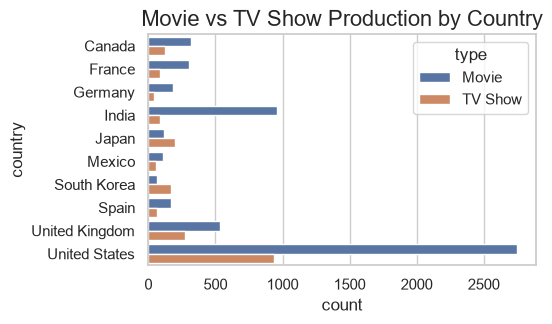

In [76]:
# Visualizing the distribution of Movies vs TV Shows production by country using a bar plot with Seaborn.
plt.figure(figsize=(5,3))

sns.barplot(
    data=country_type_analysis,
    x="count",
    y="country",
    hue="type"
)

plt.title(
    "Movie vs TV Show Production by Country",
    fontsize=16
)

plt.show()

#### 13. Genre Popularity by Content Type

In [77]:
# Prepare Genre Data
genre_type_df = df_clean.copy()

genre_type_df["listed_in"] = (
    genre_type_df["listed_in"]
    .str.split(", ")
)

genre_type_df = genre_type_df.explode(
    "listed_in"
)

In [78]:
genre_type_analysis = (
    genre_type_df
    .groupby(["listed_in","type"])
    .size()
    .reset_index(name="count")
)


top_genres = (
    genre_type_df["listed_in"]
    .value_counts()
    .head(10)
    .index
)


genre_type_analysis = genre_type_analysis[
    genre_type_analysis["listed_in"]
    .isin(top_genres)
]

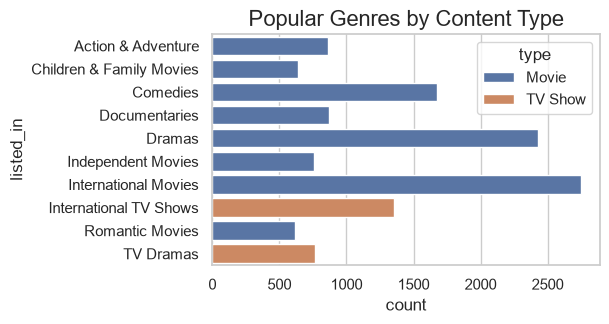

In [132]:
# Visualization
plt.figure(figsize=(5,3))

sns.barplot(
    data=genre_type_analysis,
    x="count",
    y="listed_in",
    hue="type"
)

plt.title(
    "Popular Genres by Content Type",
    fontsize=16
)

plt.show()

#### 14. Rating Preference by Content Type

In [79]:
# Analysis
rating_type = (
    df_clean
    .groupby(["rating","type"])
    .size()
    .reset_index(name="count")
)


rating_type.head()

,rating,type,count
0,66 min,Movie,1
1,74 min,Movie,1
2,84 min,Movie,1
3,G,Movie,41
4,NC-17,Movie,3


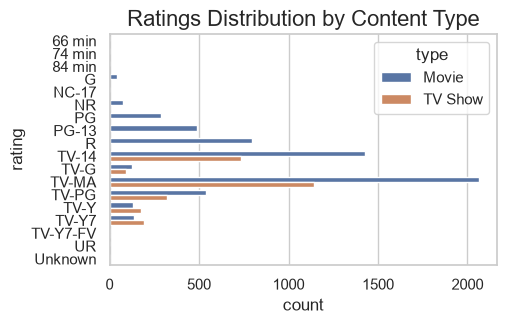

In [81]:
# Visualizing the distribution of content ratings by content type using a bar plot with Seaborn.
plt.figure(figsize=(5,3))

sns.barplot(
    data=rating_type,
    x="count",
    y="rating",
    hue="type"
)

plt.title(
    "Ratings Distribution by Content Type",
    fontsize=16
)

plt.show()

#### 15. Recent Netflix Growth Analysis

##### Analyazing content after 2018

In [82]:
#Using comnditional filtering to analyze content added to Netflix in recent years (2018 and later).
recent_content = df_clean[
    df_clean["year_added"] >= 2018
]

recent_content.shape

(7042, 13)

In [84]:
recent_genres = (
    recent_content["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

recent_genres

listed_in
International Movies        2261
Dramas                      2042
Comedies                    1432
International TV Shows      1055
Action & Adventure           741
Independent Movies           601
TV Dramas                    574
Documentaries                572
Romantic Movies              545
Children & Family Movies     524
Name: count, dtype: int64

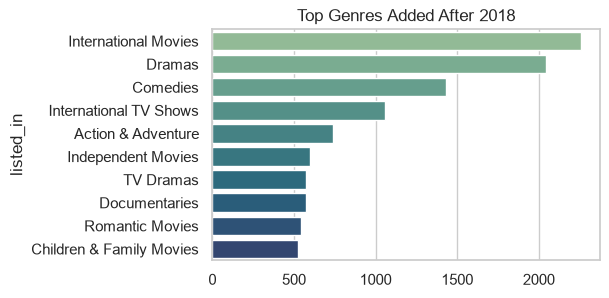

In [85]:
# Visualization of the top genres added to Netflix after 2018 using a bar plot with Seaborn.
plt.figure(figsize=(5,3))

sns.barplot(
    x=recent_genres.values,
    y=recent_genres.index,
    hue=recent_genres.index,
    palette="crest",
    legend=False
)

plt.title(
    "Top Genres Added After 2018"
)

plt.show()

#### 16. Top Actors Analysis

In [87]:
#Prepare data for actor analysis by splitting the "cast" column into individual actors and 
#removing entries with "Unknown" actors.
actor_df = df_clean.copy()

actor_df["cast"] = (
    actor_df["cast"]
    .str.split(", ")
)


actor_df = actor_df.explode("cast")


actor_df = actor_df[
    actor_df["cast"] != "Unknown"
]

In [89]:
# Top Actors
actor_counts = (
    actor_df["cast"]
    .value_counts()
    .head(10)
)

actor_counts

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

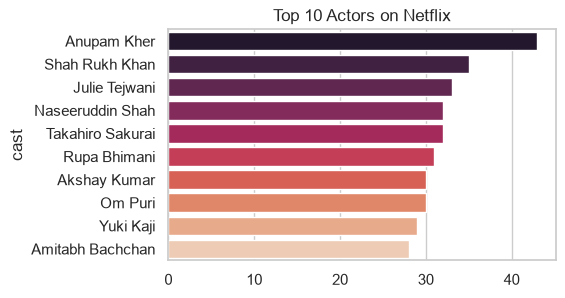

In [91]:
# Visualiztaion of the top 10 actors on Netflix using a bar plot with Seaborn.
plt.figure(figsize=(5,3))

sns.barplot(
    x=actor_counts.values,
    y=actor_counts.index,
    hue=actor_counts.index,
    palette="rocket",
    legend=False
)

plt.title(
    "Top 10 Actors on Netflix"
)

plt.show()

#### 17. Content Age Analysis

##### How old are titles when added?

In [93]:
df_clean["content_age"] = (
    df_clean["year_added"]
    -
    df_clean["release_year"]
)

df_clean[
    [
        "title",
        "release_year",
        "year_added",
        "content_age"
    ]
].head()

,title,release_year,year_added,content_age
0,Dick Johnson Is Dead,2020,2021.0,1.0
1,Blood & Water,2021,2021.0,0.0
2,Ganglands,2021,2021.0,0.0
3,Jailbirds New Orleans,2021,2021.0,0.0
4,Kota Factory,2021,2021.0,0.0


In [94]:
# Average age
average_age = (
    df_clean["content_age"]
    .mean()
)

average_age

np.float64(4.688416505626918)

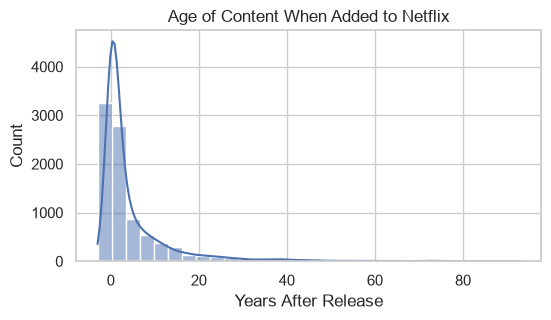

In [95]:
# Distribution of content age
plt.figure(figsize=(6,3))

sns.histplot(
    df_clean["content_age"],
    bins=30,
    kde=True
)

plt.title(
    "Age of Content When Added to Netflix"
)

plt.xlabel(
    "Years After Release"
)

plt.show()

#### 17. Country + Genre Heatmap

In [96]:
# Prepare data
country_genre = country_type_df.copy()


country_genre["listed_in"] = (
    country_genre["listed_in"]
    .str.split(", ")
)


country_genre = country_genre.explode(
    "listed_in"
)

In [97]:
# Create pivot table
pivot = pd.pivot_table(
    country_genre[
        country_genre["country"].isin(
            top_countries
        )
    ],
    index="country",
    columns="listed_in",
    values="title",
    aggfunc="count",
    fill_value=0
)

pivot.head()

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,Documentaries,Docuseries,Dramas,Faith & Spirituality,Horror Movies,Independent Movies,International Movies,International TV Shows,Kids' TV,Korean TV Shows,LGBTQ Movies,Movies,Music & Musicals,Reality TV,Romantic Movies,Romantic TV Shows,Sci-Fi & Fantasy,Science & Nature TV,Spanish-Language TV Shows,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Canada,44,0,2,3,80,4,0,94,15,6,42,11,82,3,36,44,60,25,61,1,6,5,14,9,25,2,28,4,0,13,2,0,12,30,32,8,9,9,0,5,2,49
France,37,0,0,2,23,0,6,51,23,2,44,7,167,3,10,73,207,43,43,0,1,1,8,2,22,2,10,1,0,12,5,1,6,24,27,3,2,1,0,3,0,44
Germany,33,0,0,6,17,0,0,42,15,4,21,8,80,1,7,31,94,35,8,0,1,2,8,3,10,1,13,3,0,5,5,1,2,5,19,0,2,1,0,0,0,28
India,137,0,0,3,26,0,11,323,9,5,27,9,662,4,35,167,864,66,12,0,2,0,96,6,120,12,12,0,0,17,6,3,5,26,28,7,2,3,3,3,1,92
Japan,57,61,143,1,19,0,3,9,16,1,7,2,23,0,4,7,72,151,29,0,1,2,6,9,7,21,9,0,0,1,0,1,5,10,21,5,4,0,1,6,14,5


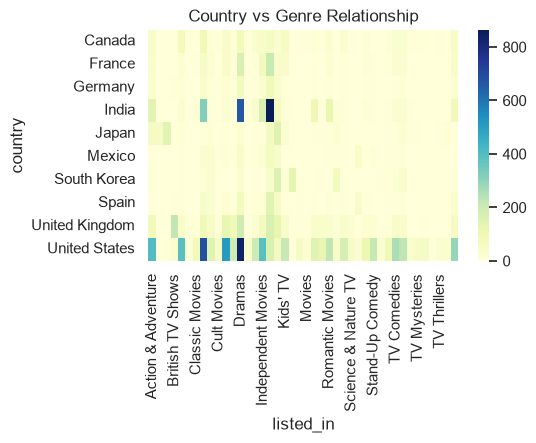

In [98]:
#Heatmap to visualize the relationship between countries and genres on Netflix using Seaborn.
plt.figure(figsize=(5,3))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title(
    "Country vs Genre Relationship"
)

plt.show()

### and All Set!